A Model that will be able to predict if a person has a heart disease based on their medical metrics

In [ ]:
#Git Commands 

!git add . 
!git commit -m"Project heart disease analysis"
!git push -u origin main
!git status

In [53]:
#TOOLS THAT I HAVE USED ARE IMPORTED IN THIS CELL

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [16]:
#MACHINE LEARNING MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#MODEL EVALUATIONS TOOLS

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

In [62]:
#IMPORTING THE DATA WE ARE GOING TO WORK WITH

df = pd.read_csv("heart-disease.csv")
df.shape #(rows, cols)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<class 'pandas.Series'>
RangeIndex: 303 entries, 0 to 302
Series name: target
Non-Null Count  Dtype
--------------  -----
303 non-null    int64
dtypes: int64(1)
memory usage: 2.5 KB
None
__________________________TYPE OF VALUES__________________
target
1    165
0    138
Name: count, dtype: int64
__________________________NULL VALUES_____________________
0
__________________________DATA DESCRIPTION__________________
count    303.000000
mean       0.544554
std        0.498835
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: target, dtype: float64


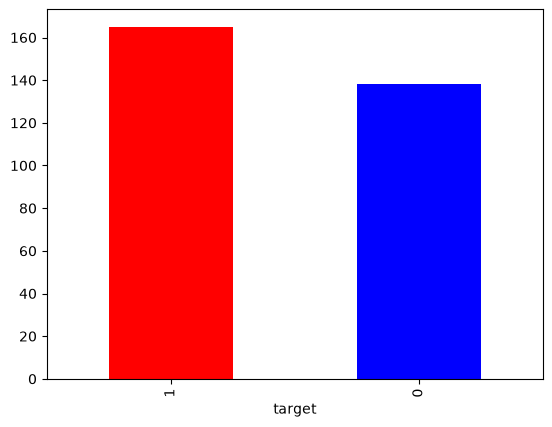

In [48]:
#DATA EXPLORATION

print(df["target"].info())
print("__________________________TYPE OF VALUES__________________")
print(df["target"].value_counts())
print("__________________________NULL VALUES_____________________")
print(df["target"].isnull().sum())

df["target"].value_counts().plot(kind = "bar",color= ['red', 'blue'] )
print("__________________________DATA DESCRIPTION__________________")
print(df["target"].describe())

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

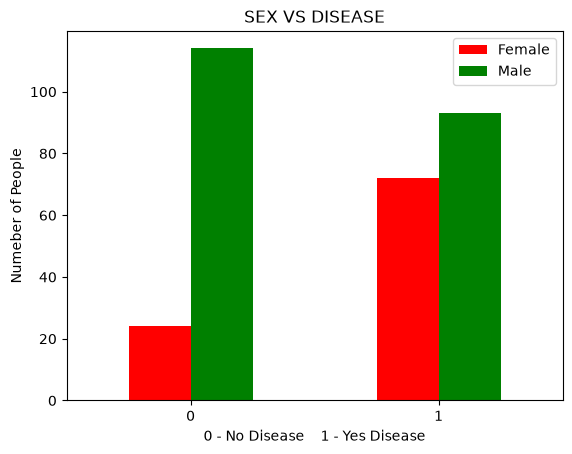

In [60]:
#FINDING PATTERS


#REALTIONSHIP BETWEEN GENDER AND OUTCOME
pd.crosstab(df['target'], df['sex'])


pd.crosstab(df['target'], df['sex']).plot(kind='bar', color =['red', 'green'])
plt.title("SEX VS DISEASE")
plt.xlabel("0 - No Disease    1 - Yes Disease" )
plt.ylabel("Numeber of People")
plt.legend(["Female", "Male"])
plt.xticks(rotation = 0)

Text(0.5, 1.0, 'COMPARISION BETWEEN AGE AND DISEASE')

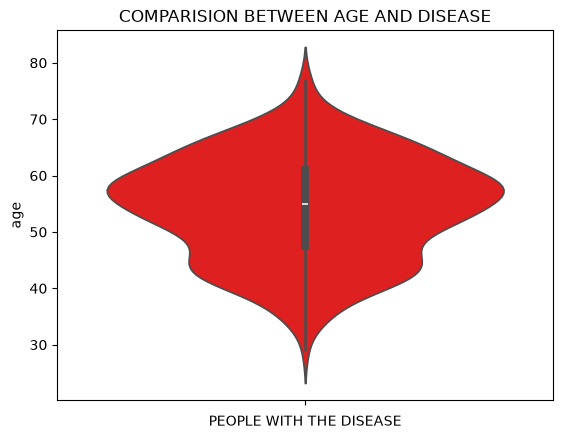

In [93]:
#COMPARISION BETWEEN AGE AND DISEASE

peopleWith = df[df['target'] == 1]
sns.violinplot(data = peopleWith, y = df['age'], color = 'red')
plt.xlabel("PEOPLE WITH THE DISEASE")
plt.title("COMPARISION BETWEEN AGE AND DISEASE")


<Axes: xlabel='age', ylabel='Count'>

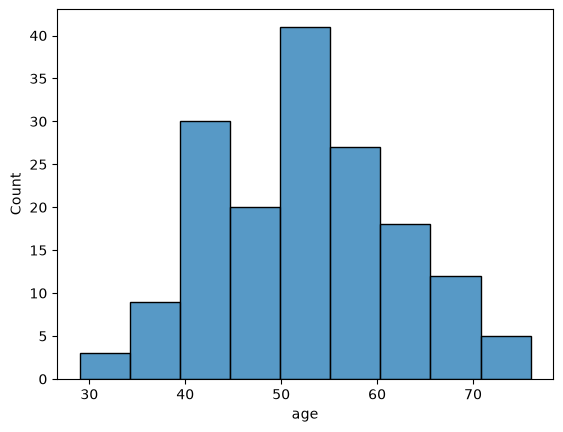

In [98]:
sns.histplot(data = peopleWith, x = peopleWith['age'])

<Axes: ylabel='Frequency'>

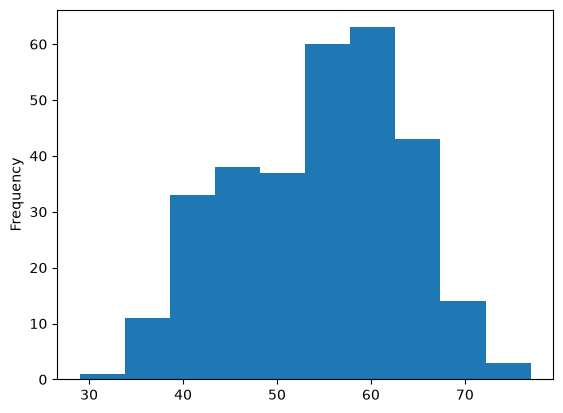

In [101]:
df.age.plot.hist()

<Axes: xlabel='target', ylabel='cp'>

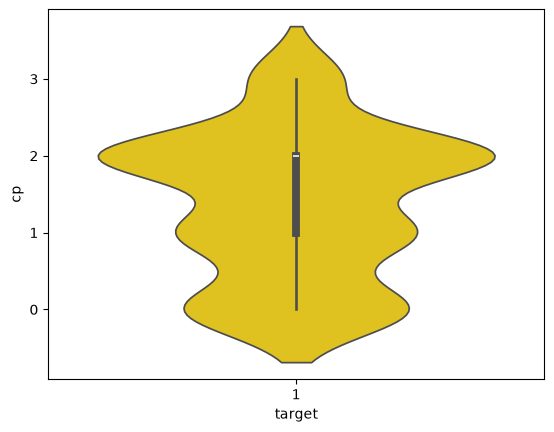

In [110]:
#Comparing hear disease with chest pain

pd.crosstab(df.target, df.cp)

sns.violinplot(data = peopleWith, x = 'target', y = 'cp', color = 'gold')

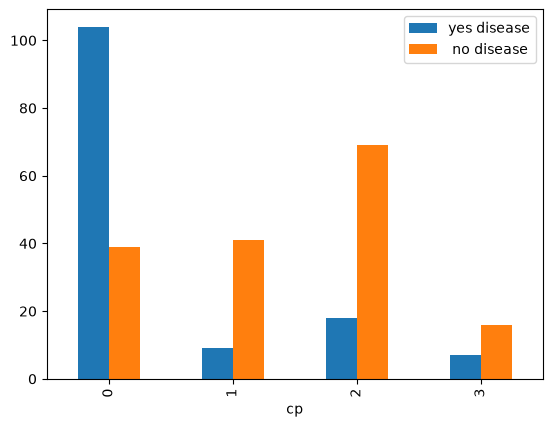

In [113]:
pd.crosstab(df.cp, df.target).plot(kind = 'bar')
plt.legend(['yes disease', ' no disease'])